In [1]:
# import
import h5py
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
from scipy.stats import sem, pearsonr, zscore, ttest_1samp, ttest_ind
import pandas as pd
from sklearn.linear_model import Ridge, RidgeCV
import pickle
import pandas as pd
import matplotlib.image as mpimg

import sys
sys.path.append('../util_code')

from functions import neuron_reliability, reliability_filtering, convert_to_deg, regression_indices, model_reliability_2, check_normality

In [19]:
# Load the data 
with h5py.File('../data/neural/230801.m1.rsvp.gratingsAdap_s3.experiment_psth_raw.h5', 'r') as f:
    r1 = f['/psth'][:]
with h5py.File('../data/neural/230801.m1.rsvp.gratingsAdap_s4.experiment_psth_raw.h5', 'r') as f:
    r2 = f['/psth'][:]
with h5py.File('../data/neural/230801.m1.rsvp.gratingsAdap_s5.experiment_psth_raw.h5', 'r') as f:
    r0 = f['/psth'][:]

print(r1.shape)
print(r2.shape)
print(r0.shape)

# Permute the axes of the arrays to match MATLAB's permute function
# Note: MATLAB's indexing starts at 1, whereas Python's starts at 0

r1 = np.transpose(r1, (1, 3, 0, 2))
r2 = np.transpose(r2, (1, 3, 0, 2))
r0 = np.transpose(r0, (1, 3, 0, 2))

# Print the sizes of the arrays

print(r1.shape)
print(r2.shape)
print(r0.shape)

(40, 10, 410, 192)
(40, 10, 410, 192)
(40, 36, 30, 192)
(10, 192, 40, 410)
(10, 192, 40, 410)
(36, 192, 40, 30)


In [20]:
# Load the metadata 
with h5py.File('../data/neural/230801.m1.rsvp.gratingsAdap_s3.experiment_psth_raw.h5', 'r') as f:
    tStart = f['/meta/start_time_ms'][()]
    bin = f['/meta/tb_ms'][()]
    tStop = f['/meta/stop_time_ms'][()]

# Adjust tStop to ensure inclusivity or the correct size, if necessary
# Example adjustment, might need fine-tuning based on actual values
adjusted_tStop = tStop - bin + 1  # +1 for inclusivity, if necessary

# Create the time array
time = np.arange(tStart, adjusted_tStop, bin) - 3200

# Ensure the size of the time array is 410, adjust as necessary
if len(time) != 410:
    # Adjust your range or logic based on actual start/stop values and requirements
    print(f"Current size is {len(time)}, which does not match the expected 410. Adjusting the logic might be necessary.")

# Print the size of the time array
print(time.shape)

(410,)


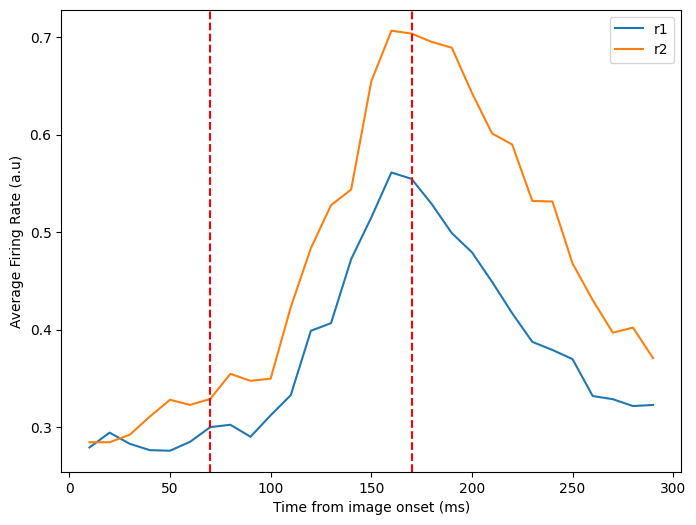

In [21]:
# Assuming 'time' and 'r1', 'r2' arrays are already defined as per previous steps

# Time conditions
time_condition = (time > 0) & (time < 300)

# Calculate the mean across the specified dimensions ignoring NaNs for r1 and r2
# For r1
mean_r1 = np.nanmean(np.nanmean(np.nanmean(r1[:, :, :, time_condition], axis=0), axis=0), axis=0)
# For r2
mean_r2 = np.nanmean(np.nanmean(np.nanmean(r2[:, :, :, time_condition], axis=0), axis=0), axis=0)

# Plotting
plt.figure(figsize=(8, 6))  # Adjust the figure size as necessary
plt.plot(time[time_condition], mean_r1, label='r1')
plt.plot(time[time_condition], mean_r2, label='r2')

# If you need to replicate the 'journalFigure' aesthetics:
plt.xlabel('Time from image onset (ms)')
plt.ylabel('Average Firing Rate (a.u)')
plt.legend()

# Uncomment the following lines if you need to add the red dashed lines
plt.axvline(x=70, color='r', linestyle='--')
plt.axvline(x=170, color='r', linestyle='--')

# journal_figure(do_save=False, filename='my_publication_figure.eps')
plt.show()

Figure 3 D

In [18]:
# import data files from M1 and M2
m1_file = h5py.File('../data/neural/230801.m1.rsvp.gratingsAdap_s5.experiment_psth_raw.h5','r')

m1_rates = m1_file['/psth'][:]
m2_rates = np.load('../data/neural/m2_season5.npy')

In [19]:
# load the ground truth center positions in pixel space 
human_im_size = 268.51895786308
gt_im_size = 256
df = pd.read_csv('../data/mae_s5_coordinates.csv') # position data
pos = np.squeeze(df['center_x'].values.reshape(-1,1))*(human_im_size/gt_im_size) # convert to the dimensions of the image that the humans made estimates on

# convert labels to eccentricity 
pos = convert_to_deg(pos, human_im_size)

In [20]:
# getting 70-170 ms and reshaping for S5 Pico and Kenny
s5_neural_m1 = np.transpose(np.nanmean(m1_rates[:,:,7:17,:],axis=2), (0,2,1)) # gets the neural data for 70-170 ms only, raised a mean of an empty slice warning bc last couple of reps are empty
s5_neural_m2 = m2_rates

/tmp/ipykernel_641396/2313639334.py:2: RuntimeWarning: Mean of empty slice
  s5_neural_m1 = np.transpose(np.nanmean(m1_rates[:,:,7:17,:],axis=2), (0,2,1)) # gets the neural data for 70-170 ms only, raised a mean of an empty slice warning bc last couple of reps are empty


In [22]:
# concatenate M1 and M2 data along the units axis
s5_neural = np.concatenate((s5_neural_m1,s5_neural_m2), axis=1)

In [23]:
# get the neuron reliabilities for 70-170 ms
rel, std_rel = neuron_reliability(s5_neural)

In [24]:
# filter neurons to include only those with r > 0.2
s5_neural = reliability_filtering(s5_neural,rel,metric=0.2)

In [25]:
# normalize the results across all the units (axis = 1) - in the combined population because we want one distribution
s5_neural = zscore(s5_neural,axis=1)

In [26]:
# reduce dimensionality for making preds, no more repetitions
s5_neural_for_preds = np.nanmean(s5_neural,axis=2)

In [27]:
# train the decoder on s5 data 
n_img = 40
n_reps = 100
n_folds = 4
alpha_values = [0.01, 0.1, 1, 10, 100]
s5_regressors = {}
s5_reg_rels = np.empty((n_reps,n_folds))
s5_em_array= np.empty((n_img,n_reps)) # 40 images by 100 predictions per image
for x in range(n_reps):
    for i in range(n_folds):
        train, test = regression_indices(n_img, number_of_groups=4, test_group=i, SEED=x)
        x_train = s5_neural_for_preds[train,:]
        y_train = pos[train]
        x_test = s5_neural_for_preds[test,:]
        ridge_cv = RidgeCV(alphas=alpha_values).fit(x_train,y_train) # performs leave-one-out cross validated alpha optimization
        best_alpha = ridge_cv.alpha_
        s5_regressors[f"reg_{x}_{i}"] = Ridge(alpha=best_alpha) 
        s5_regressors[f"reg_{x}_{i}"].fit(x_train,y_train)
        y_pred = s5_regressors[f"reg_{x}_{i}"].predict(x_test)
        s5_em_array[test, x] = np.squeeze(y_pred)
        s5_reg_rels[x,i] = model_reliability_2(s5_neural, s5_regressors[f"reg_{x}_{i}"], test)

In [30]:
#load and format S3 and S4 for M1 and M2
m1_file_s3 = h5py.File('../data/neural/230801.m1.rsvp.gratingsAdap_s3.experiment_psth_raw.h5','r')
m1_file_s4 = h5py.File('../data/neural/230801.m1.rsvp.gratingsAdap_s4.experiment_psth_raw.h5','r')

m1_rates_s3 = m1_file_s3['/psth'][:]
m1_rates_s4 = m1_file_s4['/psth'][:]
m2_rates_s3 = np.load('../data/neural/m2_season3.npy')
m2_rates_s4 = np.load('../data/neural/m2_season4.npy')

In [31]:
# getting 70-170 ms after test stimulus onset for S1-4 for Pico and Kenny
s3_neural_m1 = np.transpose(np.nanmean(m1_rates_s3[:,:,337:347,:],axis=2), (0,2,1)) 
s4_neural_m1 = np.transpose(np.nanmean(m1_rates_s4[:,:,337:347,:],axis=2), (0,2,1)) 
s3_neural_m2 = m2_rates_s3
s4_neural_m2 = m2_rates_s4

In [32]:
# concatenate M1 and M2 data along units, and filter for only reliable units 
s3_neural = reliability_filtering(np.concatenate((s3_neural_m1,s3_neural_m2),axis=1),rel,metric=0.2)
s4_neural = reliability_filtering(np.concatenate((s4_neural_m1,s4_neural_m2),axis=1),rel,metric=0.2)

In [33]:
# z-scoring across units 
s3_neural = zscore(s3_neural, axis=1)
s4_neural = zscore(s4_neural, axis=1)

In [34]:
# preparing the data for making predictions
s3_neural_for_preds = np.nanmean(s3_neural,axis=2)
s4_neural_for_preds = np.nanmean(s4_neural,axis=2)

In [35]:
# function for making predictions 
def seasons_preds(neural,best_rep):
    reg_rels = np.empty((n_reps,n_folds))
    season_rates = np.nanmean(neural,axis=2)
    em_array= np.empty((n_img,n_reps))
    for x in range(n_reps):
        for i in range(n_folds):
            test = regression_indices(n_img, number_of_groups=n_folds, test_group= i, SEED= x)[1] # use the function in functions.py to get the indices (i.e., the identifier of the images) in the train and test set
            X_test = season_rates[test,:] # index the neural data for the images used for testing from the neural variable
            y_pred = s5_regressors[f"reg_{x}_{i}"].predict(X_test)
            reg_rels[x,i] = model_reliability_2(neural, s5_regressors[f"reg_{x}_{i}"], test)
            em_array[test,x] = np.squeeze(y_pred)
    s_preds = np.nanmean(em_array[:,:best_rep], axis=1) # get correlation only up to the best rep
    s_preds_std = np.nanstd(em_array[:,:best_rep], axis=1)
    corr = np.empty(best_rep) 
    for p in range(best_rep): # edited to be correlation with s5 predictions
        corr_temp = pearsonr(s5_em_array[:,p], em_array[:,p])[0] # correlate the predictions from each shuffle with s5 preds
        corr[p] = corr_temp/np.sqrt(np.nanmean(reg_rels,axis=1)[p])
    s_corr = np.nanmean(corr)
    s_corr_std = np.nanstd(corr)
    return corr, s_preds, s_preds_std, s_corr, s_corr_std, em_array

In [36]:
# getting the predictions for each season
full_s3x_corr, s3_preds, s3_preds_std, s3_corr, s3_corr_std, s3_pred_array = seasons_preds(s3_neural,100)
full_s4x_corr, s4_preds, s4_preds_std, s4_corr, s4_corr_std, s4_pred_array = seasons_preds(s4_neural,100)

In [37]:
# save the correlations to use in figure 5
np.save('../data/s3xpreds_s5_corr.npy',full_s3x_corr)
np.save('../data/s4xpreds_s5_corr.npy',full_s4x_corr)

In [38]:
# plotting range
pos_range = np.linspace(min(pos),max(pos))

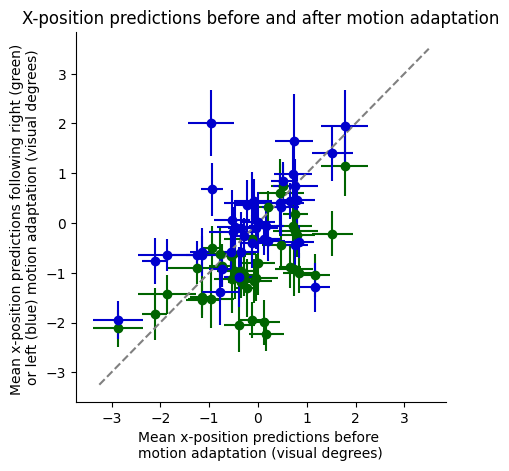

In [39]:
# s3 vs s4 predictions
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

best_rep = 100
s5_preds = np.nanmean(s5_em_array[:,:best_rep],axis=1)
s5_preds_std = np.nanstd(s5_em_array[:,:best_rep],axis=1)

plt.errorbar(s5_preds,s3_preds,xerr=s5_preds_std,yerr=s3_preds_std, fmt='o', color='darkgreen') # rightward motion
plt.errorbar(s5_preds,s4_preds,xerr=s5_preds_std,yerr=s4_preds_std, fmt='o', color='mediumblue') # leftward motion
plt.plot(pos_range,pos_range, color='grey', linestyle='--')

plt.xlabel('Mean x-position predictions before \nmotion adaptation (visual degrees)')
plt.ylabel('Mean x-position predictions following right (green) \nor left (blue) motion adaptation (visual degrees)')
plt.title('X-position predictions before and after motion adaptation')

x0,x1 = plt.gca().get_xlim()
y0,y1 = plt.gca().get_ylim()

plt.gca().set_aspect(abs(x1-x0)/abs(y1-y0))

# plt.savefig('/home/eyakub/scratch/x_s34.eps', format='eps', bbox_inches='tight')

In [40]:
# set-up for plotting predictions on the image 
bounding_box_info = pd.read_csv('../data/mae_s5_coordinates.csv') # change this to the location of the csv
image_id = 28 # change this to the id of the image you want to visualize, apparently image 24, image 39, image 38 has the biggest delta
image_file_path = f'../data/season5/im{image_id}.png' # change this to the path of the images (with the id)

In [41]:
# convert the predictions into pixel space for plotting - to recreate the predictions for y-position, run fig3_ypreds.ipynb

def convert_to_px(deg,im_size):
    '''
    Function to convert predictions in visual degrees to pixels for plotting. 
    deg - ndarray
    im_size - int or float
    '''
    return np.array(deg*im_size/16 + im_size/2).astype(int)

s3x_px = convert_to_px(s3_pred_array, human_im_size)
s4x_px = convert_to_px(s4_pred_array, human_im_size)

s3y = np.load('../data/s3y_neural_pred_array.npy')
s4y = np.load('../data/s4y_neural_pred_array.npy')

s3y_px = convert_to_px(s3y, human_im_size)
s4y_px = convert_to_px(s4y, human_im_size)

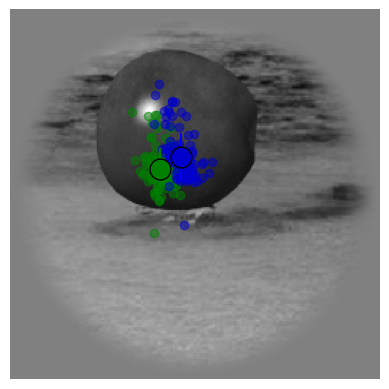

In [42]:
# load the image and the position estimates 

# Plot the image
fig, ax = plt.subplots()
img = mpimg.imread(image_file_path)

ax.imshow(img)

# Want to plot the trial-by-trial responses scaled down to the 256x256 image 
# (recall: the predictions were computed on images of slightly different size so need to scale their responses to the image size)
gt_im_size = 256
s3x_scaled = s3x_px[image_id,:]*(gt_im_size/human_im_size)
s3y_scaled = s3y_px[image_id,:]*(gt_im_size/human_im_size)
s4x_scaled = s4x_px[image_id,:]*(gt_im_size/human_im_size)
s4y_scaled = s4y_px[image_id,:]*(gt_im_size/human_im_size)

# plot all the individual estimates 
plt.scatter(s3x_scaled,s3y_scaled,color='green',alpha=0.5)
plt.scatter(s4x_scaled,s4y_scaled,color='mediumblue',alpha=0.5)

# plot the average and sem of the estimates
plt.errorbar(np.nanmean(s3x_scaled),np.nanmean(s3y_scaled),np.nanstd(s3y_scaled),np.nanstd(s3x_scaled),'go',mec='black',mfc='green',markersize=15,alpha=1)
plt.errorbar(np.nanmean(s4x_scaled),np.nanmean(s4y_scaled),np.nanstd(s4y_scaled),np.nanstd(s4x_scaled),'bo', mec='black', mfc= 'mediumblue',markersize=15,alpha=1)

plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.gca().set_axis_off()

# plt.savefig('/home/eyakub/scratch/s34_neural_estimates.eps', format='eps', bbox_inches='tight')

Figure 3 E - please run Figure 3 D code before this section

In [43]:
# compute the deltas 
mean_delta = np.nanmean(s4_preds-s3_preds)
sem_delta = sem(s4_preds-s3_preds)
std_delta = np.nanstd(np.nanmean(s4_pred_array-s3_pred_array,axis=0))

print(f"mean delta s4 vs s3: {mean_delta} +/- {std_delta}")

mean delta s4 vs s3: 0.8412620639119179 +/- 0.056583974470074266


In [44]:
# store the deltas for use in figure 5 
np.save('../data/pixel_space_neurals34_deltax.npy', s4_preds-s3_preds)

In [45]:
# check whether assumptions violated for deltas 
print(f"s4-s3: {check_normality('singlet',s4_preds-s3_preds)}")

s4-s3: 0.09539783000946045


In [46]:
# assumptions not violated 
print(f"s4-s3: {ttest_1samp(s4_preds-s3_preds,0)}")

s4-s3: TtestResult(statistic=6.245833490964673, pvalue=2.359686279348493e-07, df=39)


In [47]:
# load the human deltas - you can recompute these using figure2.ipynb
with open('../data/human_deltax_dict.pkl', 'rb') as f:
    human_deltax_dict = pickle.load(f)

human_deltax_dict.keys()

dict_keys(['s4_v_s3', 's3_v_s5', 's4_v_s5'])

In [48]:
# load and compile the deltas across the number of neurons - you can recompute these using fig3_deltas.sh
d43x_1050 = np.load('../data/ds43x_10-50_ecc_reps.npy')
d43x_60110 = np.load('../data/ds43x_60-110_ecc_reps.npy')
d43x_on = np.concatenate((d43x_1050,d43x_60110),axis=0)

In [49]:
# test whether the human and neural deltas are significantly different across subsamples of neurons 
s43_hvon = []

for i in range(d43x_on.shape[0]):
    s43_hvon.append(ttest_ind(human_deltax_dict['s4_v_s3'],d43x_on[i]).pvalue)

In [50]:
# test the human and final neural deltas 
print(f"s4 vs s3: {ttest_ind(human_deltax_dict['s4_v_s3'],s4_preds-s3_preds)}")

s4 vs s3: TtestResult(statistic=-3.6559353065436633, pvalue=0.0004630353092723262, df=78.0)


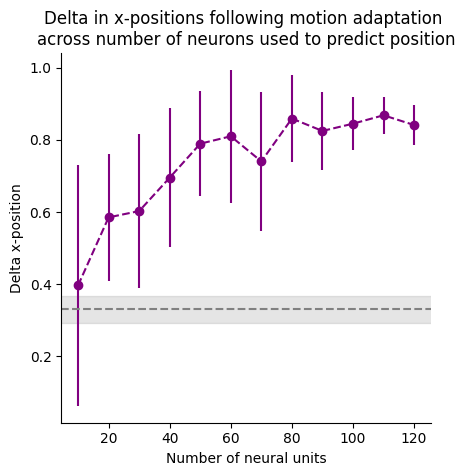

In [51]:
# plot deltas across number of neural units used
mean_d43_on = np.nanmean(np.nanmean(d43x_on,axis=-1),axis=1)
std_d43_on = np.nanstd(np.nanmean(d43x_on,axis=-1),axis=1)
plot_d43 = np.concatenate((mean_d43_on, np.array([mean_delta])))
std_d43 = np.concatenate((std_d43_on, np.array([std_delta])))
plt_range = np.arange(10,130,10)

plt.errorbar(plt_range, plot_d43, yerr=std_d43, linestyle='--', marker='o', color='purple')
plt.axhline(np.nanmean(human_deltax_dict['s4_v_s3']), linestyle='--', color='grey')
rectangle4 = Rectangle((0,np.nanmean(human_deltax_dict['s4_v_s3'])-sem(human_deltax_dict['s4_v_s3'])),130,2*sem(human_deltax_dict['s4_v_s3']),color='grey',alpha=0.2)
plt.gca().add_patch(rectangle4)

plt.xlabel('Number of neural units')
plt.ylabel('Delta x-position')
plt.title('Delta in x-positions following motion adaptation \nacross number of neurons used to predict position')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
# plt.ylim(0,0.5)
x0, x1 = plt.gca().get_xlim()
y0, y1 = plt.gca().get_ylim()
plt.gca().set_aspect(abs(x1 - x0) / abs(y1 - y0))

# plt.savefig('/home/eyakub/scratch/d43_neural_dx_over_neurons.eps', format='eps', bbox_inches='tight')